***REQUIREMENTS***

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df=pd.read_csv("/content/ONINE_FOOD_DELIVERY_ANALYSIS.csv")

In [ ]:
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,NaN,Central,RES936,Restaurant_29,Chinese,10/20/2024,...,NaN,UPI,Delivered,NaN,DP563,5.0,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,NaN,Female,Chennai,North,RES689,Restaurant_419,Chinese,8/12/2024,...,4849.0,COD,Delivered,NaN,DP369,5.0,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,NaN,Male,Delhi,NaN,RES723,Restaurant_244,Arabian,12/8/2024,...,737.0,Wallet,Delivered,NaN,DP580,4.0,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,NaN,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,10/8/2024,...,NaN,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,NaN,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2/4/2024,...,352.0,Card,Delivered,NaN,DP728,2.0,4.4,Weekend,False,0.12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Order_ID             100000 non-null  object 
 1   Customer_ID          100000 non-null  object 
 2   Customer_Age         49907 non-null   float64
 3   Customer_Gender      75144 non-null   object 
 4   City                 83274 non-null   object 
 5   Area                 83315 non-null   object 
 6   Restaurant_ID        100000 non-null  object 
 7   Restaurant_Name      100000 non-null  object 
 8   Cuisine_Type         83115 non-null   object 
 9   Order_Date           98986 non-null   object 
 10  Order_Time           98002 non-null   object 
 11  Delivery_Time_Min    66641 non-null   float64
 12  Distance_km          66530 non-null   float64
 13  Order_Value          66673 non-null   float64
 14  Discount_Applied     83285 non-null   float64
 15  Final_Amount      

Preprocessing

Handle null values

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Customer_Age,50093
Customer_Gender,24856
City,16726
Area,16685
Restaurant_ID,0
Restaurant_Name,0
Cuisine_Type,16885
Order_Date,1014


In [ ]:
df["Customer_Age"].median()


39.0

In [ ]:
df["Customer_Age"].mean()

np.float64(38.97651632035586)

In [ ]:
df["Customer_Age"].mode()

,Customer_Age
0,27.0


In [ ]:
df['Customer_Age'].fillna(df['Customer_Age'].median(), inplace=True)


/tmp/ipython-input-3352521858.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Customer_Age'].fillna(df['Customer_Age'].median(), inplace=True)


In [ ]:
df['Customer_Gender'].fillna('unknown', inplace=True)


/tmp/ipython-input-2897565132.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Customer_Gender'].fillna('unknown', inplace=True)


In [ ]:
df['Cuisine_Type'].fillna('unknown_cuisine', inplace=True)


/tmp/ipython-input-1795655130.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Cuisine_Type'].fillna('unknown_cuisine', inplace=True)


In [ ]:
df.dropna(subset=['Order_Date'], inplace=True)


In [ ]:
df['Order_Time'].fillna(df['Order_Time'].mode()[0], inplace=True)


/tmp/ipython-input-2869848219.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Order_Time'].fillna(df['Order_Time'].mode()[0], inplace=True)


In [ ]:
median_delivery = df.loc[
    df['Order_Status'] == 'Delivered', 'Delivery_Time_Min'
].median()

df.loc[
    (df['Order_Status'] == 'Delivered') &
    (df['Delivery_Time_Min'].isnull()),
    'Delivery_Time_Min'
] = median_delivery


In [ ]:
median_distance = df['Distance_km'].median()
df['Distance_km'].fillna(median_distance, inplace=True)


/tmp/ipython-input-2850934516.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Distance_km'].fillna(median_distance, inplace=True)


In [ ]:
df['Order_Value'].fillna(df['Order_Value'].median(), inplace=True)


/tmp/ipython-input-2254869392.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Order_Value'].fillna(df['Order_Value'].median(), inplace=True)


In [ ]:
df['Final_Amount'] = df['Final_Amount'].fillna(
    df['Order_Value'] - df['Discount_Applied']
)


In [ ]:
df['Payment_Mode'].fillna('unknown', inplace=True)


/tmp/ipython-input-316882877.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Payment_Mode'].fillna('unknown', inplace=True)


In [ ]:
df['Cancellation_Reason'].fillna('not_cancelled', inplace=True)


/tmp/ipython-input-3467474630.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Cancellation_Reason'].fillna('not_cancelled', inplace=True)


In [ ]:
df.loc[
    (df['Order_Status'] == 'Delivered') &
    (df['Delivery_Rating'].isnull()),
    'Delivery_Rating'
] = df['Delivery_Rating'].median()


In [ ]:
df['City'].fillna('unknown_city', inplace=True)


/tmp/ipython-input-572781572.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['City'].fillna('unknown_city', inplace=True)


In [ ]:
df['Area'].fillna('unknown_area', inplace=True)


/tmp/ipython-input-189807419.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Area'].fillna('unknown_area', inplace=True)


In [ ]:
median_delivery = df.loc[
    df['Order_Status'] == 'Delivered',
    'Delivery_Time_Min'
].median()

df.loc[
    (df['Order_Status'] == 'Delivered') &
    (df['Delivery_Time_Min'].isnull()),
    'Delivery_Time_Min'
] = median_delivery


In [ ]:
df['Discount_Applied'].fillna(0, inplace=True)


/tmp/ipython-input-427315198.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Discount_Applied'].fillna(0, inplace=True)


In [ ]:
df['Final_Amount'] = df['Final_Amount'].fillna(
    df['Order_Value'] - df['Discount_Applied']
)


In [ ]:
median_rating = df.loc[
    df['Order_Status'] == 'Delivered',
    'Delivery_Rating'
].median()

df.loc[
    (df['Order_Status'] == 'Delivered') &
    (df['Delivery_Rating'].isnull()),
    'Delivery_Rating'
] = median_rating


In [ ]:
median_rating = df.loc[
    df['Order_Status'] == 'Delivered',
    'Delivery_Rating'
].median()

df.loc[
    (df['Order_Status'] == 'Delivered') &
    (df['Delivery_Rating'].isnull()),
    'Delivery_Rating'
] = median_rating


In [ ]:
df.loc[df['Order_Status'] == 'Cancelled', 'Delivery_Time_Min'] = np.nan



In [ ]:
df.loc[df['Order_Status'] == 'Cancelled', 'Delivery_Rating'] = np.nan


In [ ]:
def peak_hour_safe(time):
    try:
        hour = int(time.split(':')[0])
        if 7 <= hour <= 10:
            return 'morning'
        elif 12 <= hour <= 15:
            return 'lunch'
        elif 19 <= hour <= 22:
            return 'dinner'
        else:
            return 'off_peak'
    except:
        return 'unknown'

df['Peak_Hour'] = df['Order_Time'].apply(peak_hour_safe)


In [ ]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Customer_Age', 'Customer_Gender', 'City',
       'Area', 'Restaurant_ID', 'Restaurant_Name', 'Cuisine_Type',
       'Order_Date', 'Order_Time', 'Delivery_Time_Min', 'Distance_km',
       'Order_Value', 'Discount_Applied', 'Final_Amount', 'Payment_Mode',
       'Order_Status', 'Cancellation_Reason', 'Delivery_Partner_ID',
       'Delivery_Rating', 'Restaurant_Rating', 'Order_Day', 'Peak_Hour',
       'Profit_Margin'],
      dtype='object')

In [ ]:
df[df["Order_Status"]=="Cancelled"].count()

,0
Order_ID,14886
Customer_ID,14886
Customer_Age,14886
Customer_Gender,14886
City,14886
Area,14886
Restaurant_ID,14886
Restaurant_Name,14886
Cuisine_Type,14886
Order_Date,14886


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Customer_Age,0
Customer_Gender,0
City,0
Area,0
Restaurant_ID,0
Restaurant_Name,0
Cuisine_Type,0
Order_Date,0


Handle Outliers

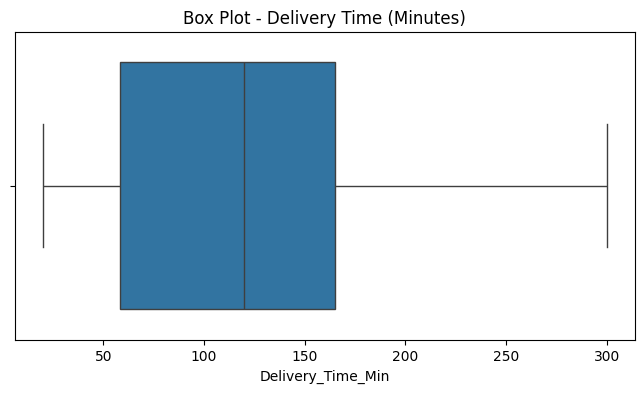

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.boxplot(x=df[df['Order_Status']=='Delivered']['Delivery_Time_Min'])
plt.title("Box Plot - Delivery Time (Minutes)")
plt.show()


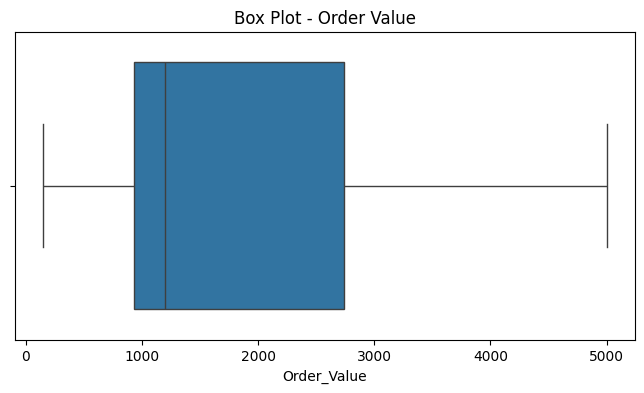

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Order_Value'])
plt.title("Box Plot - Order Value")
plt.show()


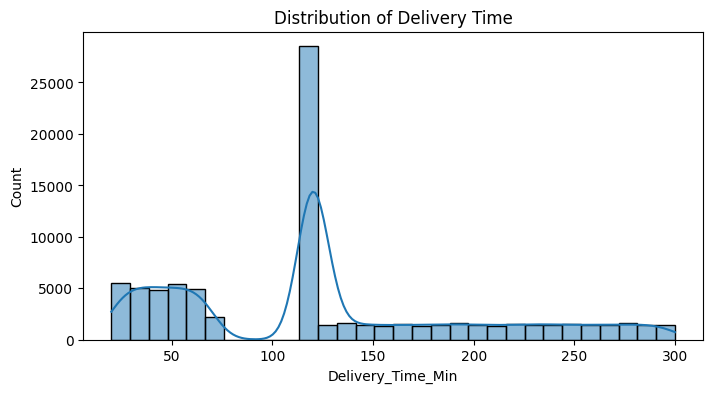

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(
    df[df['Order_Status']=='Delivered']['Delivery_Time_Min'],
    bins=30,
    kde=True
)
plt.title("Distribution of Delivery Time")
plt.show()


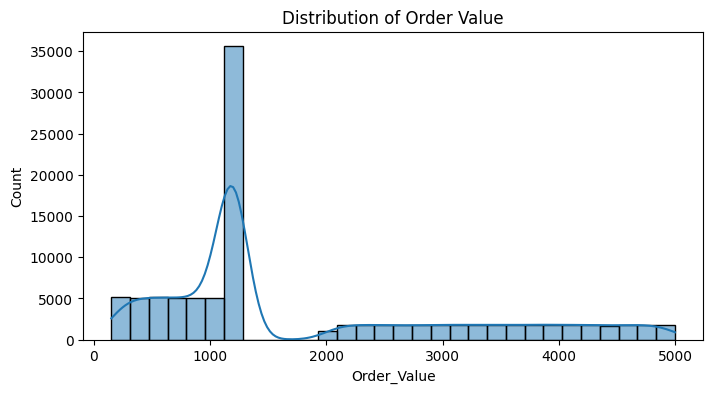

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['Order_Value'], bins=30, kde=True)
plt.title("Distribution of Order Value")
plt.show()


In [ ]:
delivered_df = df[df['Order_Status'] == 'Delivered']


In [ ]:
Q1 = delivered_df['Delivery_Time_Min'].quantile(0.25)
Q3 = delivered_df['Delivery_Time_Min'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR


In [ ]:
df.loc[
    df['Delivery_Time_Min'] > upper_limit,
    'Delivery_Time_Min'
] = upper_limit

df.loc[
    df['Delivery_Time_Min'] < lower_limit,
    'Delivery_Time_Min'
] = lower_limit


In [ ]:
Q1 = df['Order_Value'].quantile(0.25)
Q3 = df['Order_Value'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR


In [ ]:
df['Order_Value'] = df['Order_Value'].clip(
    lower=lower_limit,
    upper=upper_limit
)


In [ ]:
df[['Delivery_Time_Min', 'Order_Value']].describe()


,Delivery_Time_Min,Order_Value
count,84100.000000,98986.000000
mean,124.976552,1787.098650
std,74.247759,1335.656676
min,20.000000,150.000000
25%,58.000000,935.000000
50%,120.000000,1197.000000
75%,165.000000,2743.000000
max,300.000000,5000.000000


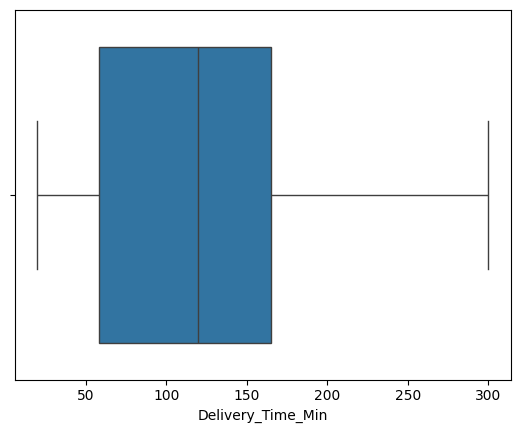

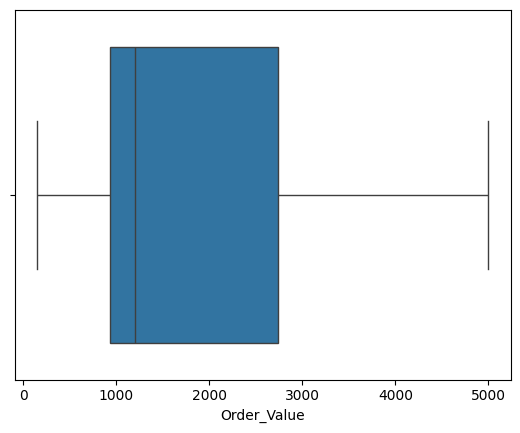

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Delivery_Time_Min'])
plt.show()

sns.boxplot(x=df['Order_Value'])
plt.show()


Correcting invalid values (ratings > 5, negative profit margin)

In [ ]:
df[(df['Delivery_Rating'] > 5) | (df['Delivery_Rating'] < 1)]


,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin


Standardizing categorical values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98986 entries, 0 to 99998
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order_ID             98986 non-null  object 
 1   Customer_ID          98986 non-null  object 
 2   Customer_Age         98986 non-null  float64
 3   Customer_Gender      98986 non-null  object 
 4   City                 98986 non-null  object 
 5   Area                 98986 non-null  object 
 6   Restaurant_ID        98986 non-null  object 
 7   Restaurant_Name      98986 non-null  object 
 8   Cuisine_Type         98986 non-null  object 
 9   Order_Date           98986 non-null  object 
 10  Order_Time           98986 non-null  object 
 11  Delivery_Time_Min    84100 non-null  float64
 12  Distance_km          98986 non-null  float64
 13  Order_Value          98986 non-null  float64
 14  Discount_Applied     98986 non-null  float64
 15  Final_Amount         98986 non-null  floa

In [ ]:
categorical_cols = [
    'Customer_Gender',
    'City',
    'Area',
    'Restaurant_Name',
    'Cuisine_Type',
    'Payment_Mode',
    'Order_Status',
    'Cancellation_Reason',
    'Order_Day',
    'Peak_Hour'
]


In [ ]:
for col in categorical_cols:
    df[col] = df[col].str.lower().str.strip()


🔹 Step 4: Exploratory Data Analysis (EDA)
EDA is performed to uncover hidden patterns and trends:
Distribution of order values and delivery time


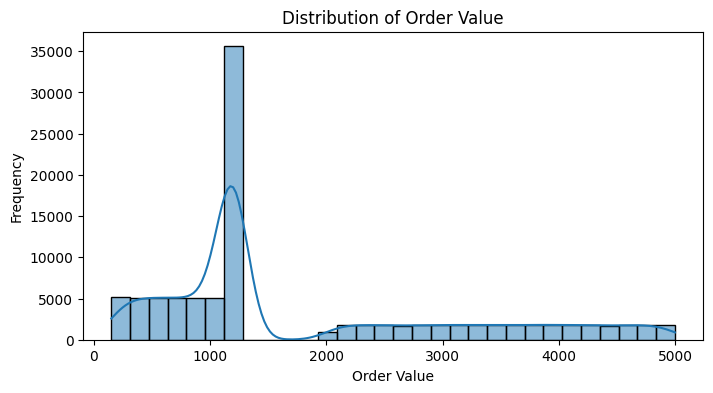

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.histplot(df['Order_Value'], bins=30, kde=True)
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()


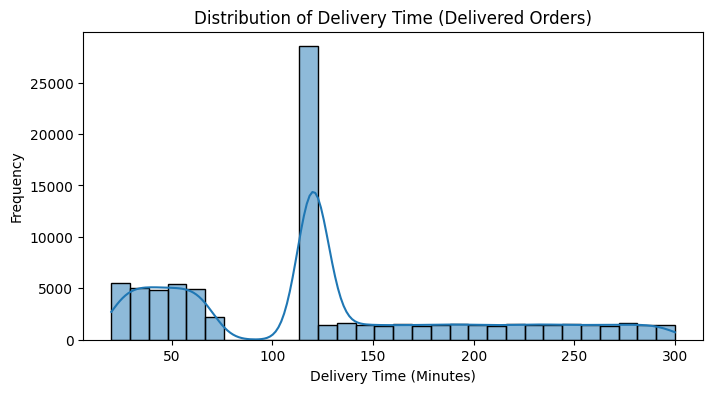

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(
    delivered_df['Delivery_Time_Min'],
    bins=30,
    kde=True
)
plt.title("Distribution of Delivery Time (Delivered Orders)")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Frequency")
plt.show()


/tmp/ipython-input-2116125995.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_orders.index, y=city_orders.values, palette='viridis')


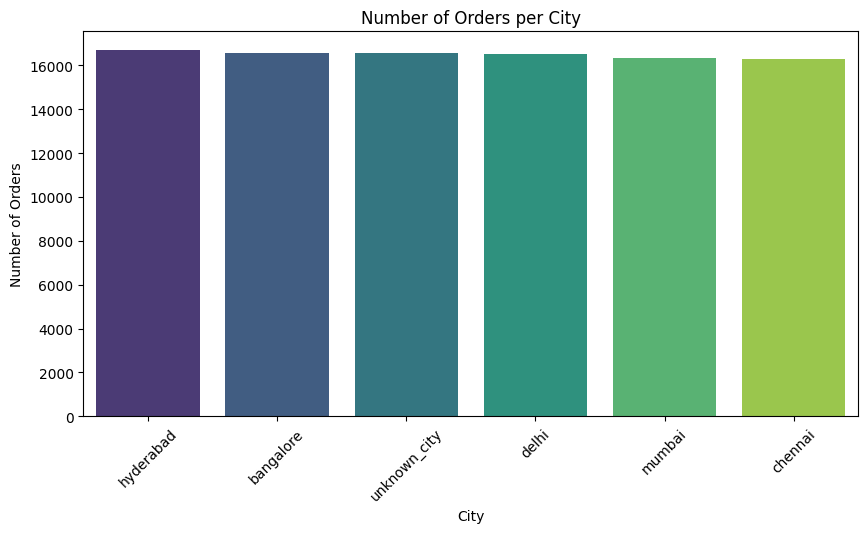

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

city_orders = df.groupby('City')['Order_ID'].count().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=city_orders.index, y=city_orders.values, palette='viridis')
plt.xticks(rotation=45)
plt.ylabel("Number of Orders")
plt.title("Number of Orders per City")
plt.show()


/tmp/ipython-input-2473464023.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_revenue.index, y=city_revenue.values, palette='magma')


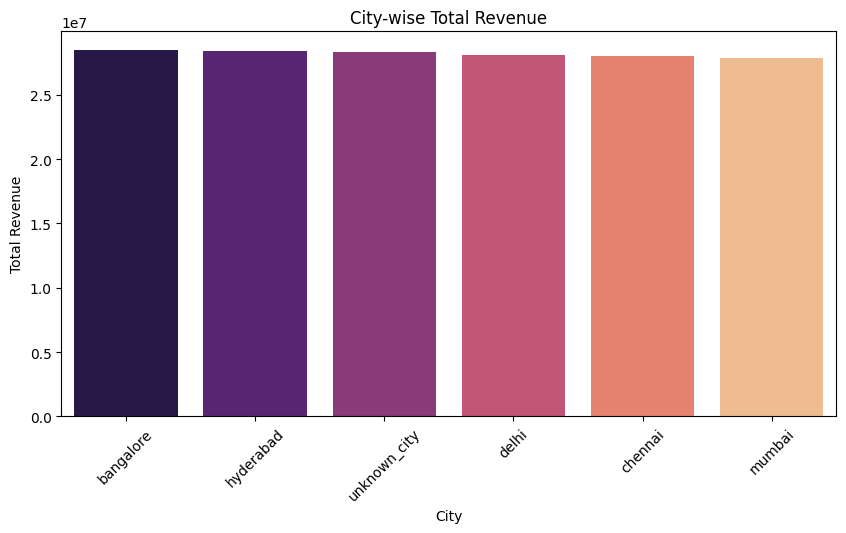

In [ ]:
city_revenue = df.groupby('City')['Final_Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=city_revenue.index, y=city_revenue.values, palette='magma')
plt.xticks(rotation=45)
plt.ylabel("Total Revenue")
plt.title("City-wise Total Revenue")
plt.show()


/tmp/ipython-input-1144069217.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_avg_order.index, y=city_avg_order.values, palette='coolwarm')


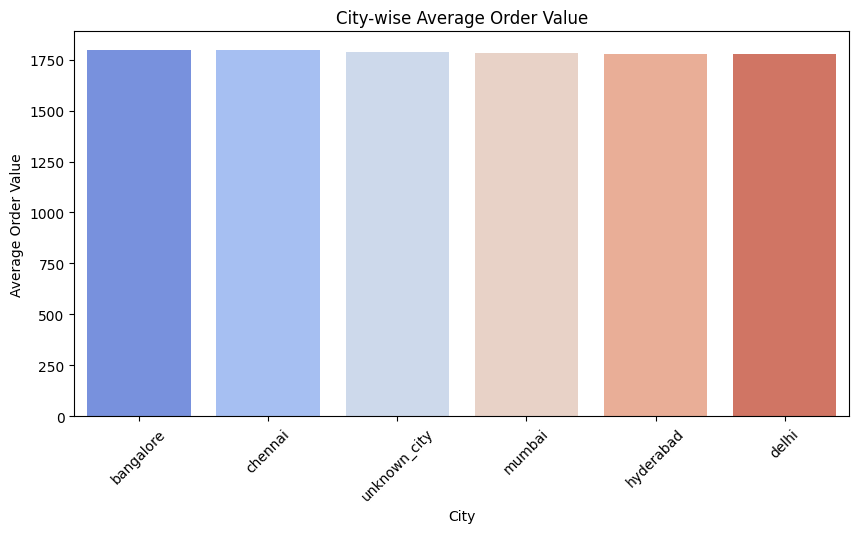

In [ ]:
city_avg_order = df.groupby('City')['Order_Value'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=city_avg_order.index, y=city_avg_order.values, palette='coolwarm')
plt.xticks(rotation=45)
plt.ylabel("Average Order Value")
plt.title("City-wise Average Order Value")
plt.show()


/tmp/ipython-input-1329357828.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_orders.index, y=cuisine_orders.values, palette='Set2')


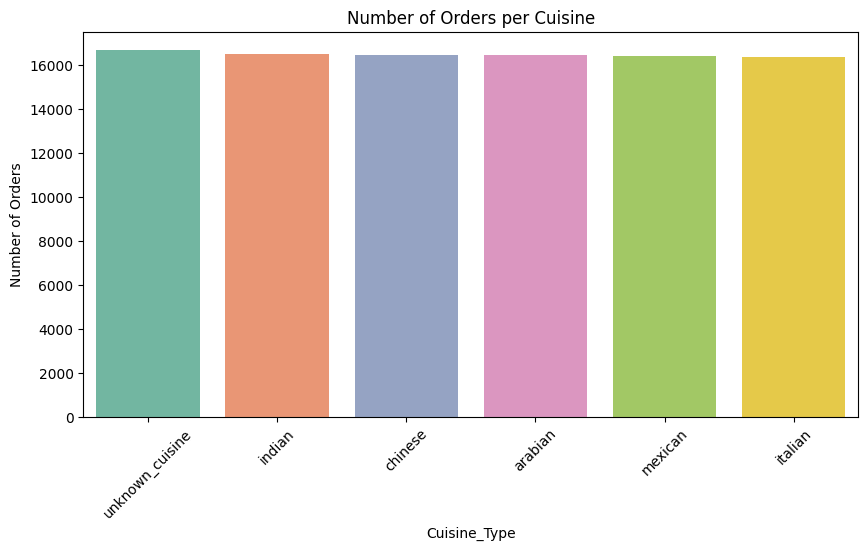

In [ ]:
cuisine_orders = df.groupby('Cuisine_Type')['Order_ID'].count().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=cuisine_orders.index, y=cuisine_orders.values, palette='Set2')
plt.xticks(rotation=45)
plt.ylabel("Number of Orders")
plt.title("Number of Orders per Cuisine")
plt.show()


/tmp/ipython-input-3889048966.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_revenue.index, y=cuisine_revenue.values, palette='Set1')


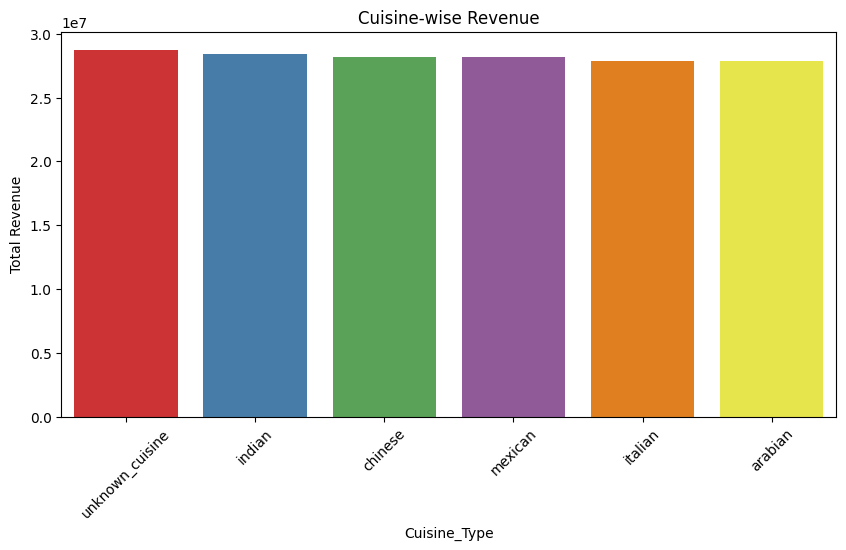

In [ ]:
cuisine_revenue = df.groupby('Cuisine_Type')['Final_Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=cuisine_revenue.index, y=cuisine_revenue.values, palette='Set1')
plt.xticks(rotation=45)
plt.ylabel("Total Revenue")
plt.title("Cuisine-wise Revenue")
plt.show()


/tmp/ipython-input-3771284353.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_avg_order.index, y=cuisine_avg_order.values, palette='cool')


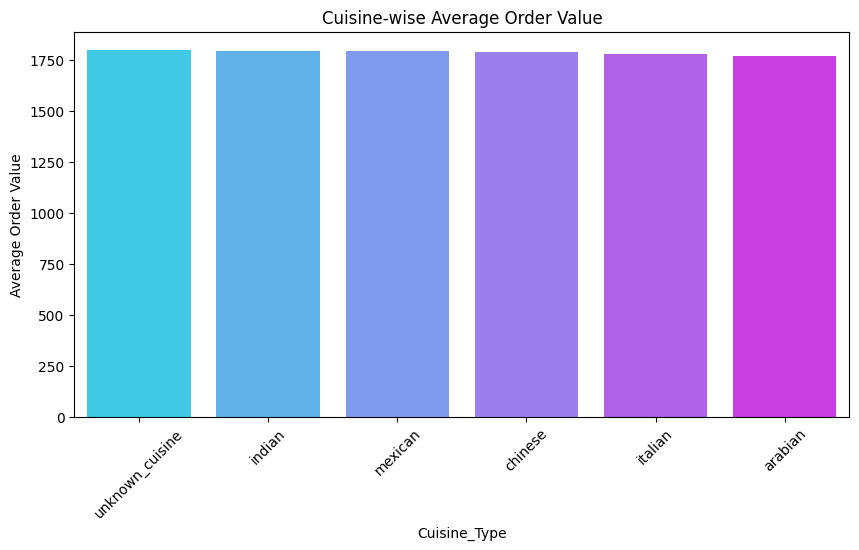

In [ ]:
cuisine_avg_order = df.groupby('Cuisine_Type')['Order_Value'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=cuisine_avg_order.index, y=cuisine_avg_order.values, palette='cool')
plt.xticks(rotation=45)
plt.ylabel("Average Order Value")
plt.title("Cuisine-wise Average Order Value")
plt.show()


In [ ]:
import pandas as pd

# Convert Order_Date to datetime if not already
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Create Weekday (Monday=0, Sunday=6)
df['Day_of_Week'] = df['Order_Date'].dt.dayofweek

# Flag weekends
df['Day_Type'] = df['Day_of_Week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')


/tmp/ipython-input-2737065178.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_orders.index, y=day_orders.values, palette='pastel')


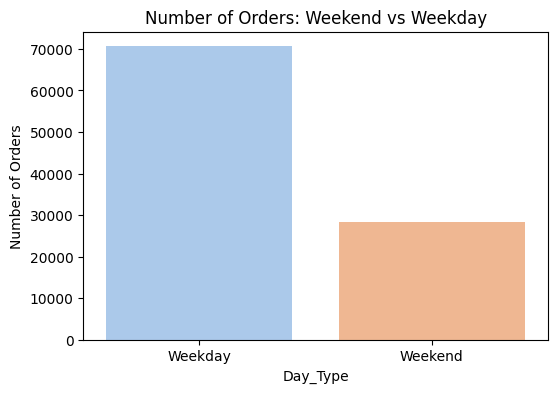

In [ ]:
day_orders = df.groupby('Day_Type')['Order_ID'].count()

plt.figure(figsize=(6,4))
sns.barplot(x=day_orders.index, y=day_orders.values, palette='pastel')
plt.title("Number of Orders: Weekend vs Weekday")
plt.ylabel("Number of Orders")
plt.show()


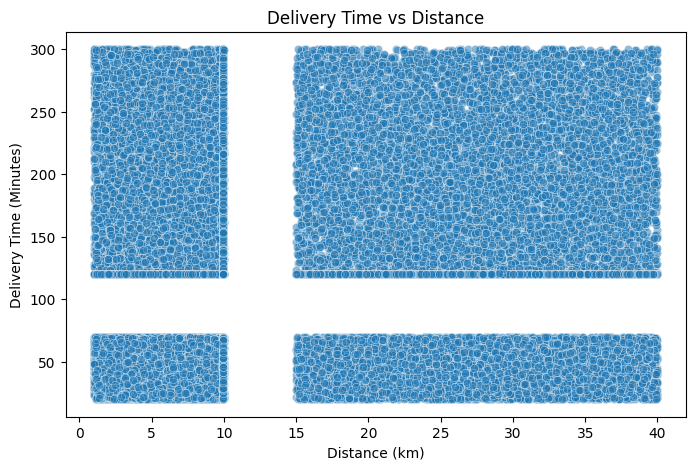

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Distance_km',
    y='Delivery_Time_Min',
    data=delivered_df,
    alpha=0.5
)
plt.title("Delivery Time vs Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (Minutes)")
plt.show()


In [ ]:
delivered_df[['Distance_km','Delivery_Time_Min']].corr()


,Distance_km,Delivery_Time_Min
Distance_km,1.00000,0.00456
Delivery_Time_Min,0.00456,1.00000


In [ ]:
bins = [0, 2, 5, 10, 20, 50]
labels = ['0-2','2-5','5-10','10-20','20+']
delivered_df['Distance_Bucket'] = pd.cut(delivered_df['Distance_km'], bins=bins, labels=labels)


/tmp/ipython-input-2640374631.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered_df['Distance_Bucket'] = pd.cut(delivered_df['Distance_km'], bins=bins, labels=labels)


/tmp/ipython-input-3050252849.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


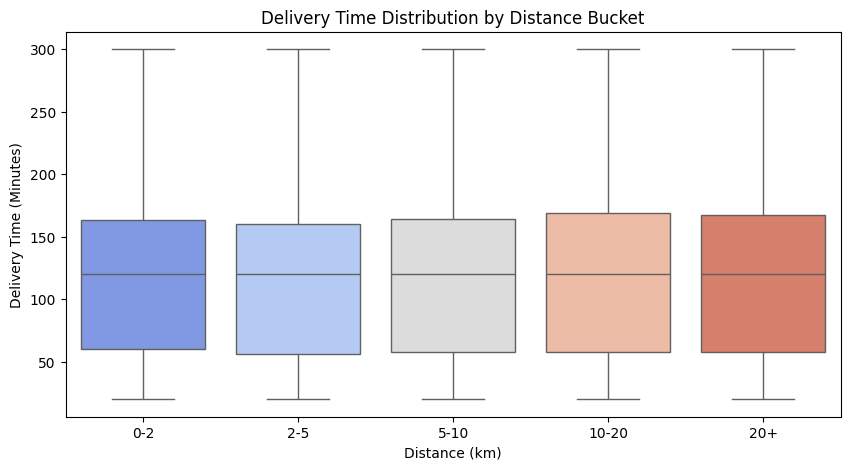

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x='Distance_Bucket',
    y='Delivery_Time_Min',
    data=delivered_df,
    palette='coolwarm'
)
plt.title("Delivery Time Distribution by Distance Bucket")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (Minutes)")
plt.show()



In [ ]:
cancelled_df = df[df['Order_Status'] == 'cancelled'].copy()


In [ ]:
cancelled_df['Cancellation_Reason'].value_counts()

,count
Cancellation_Reason,
not_cancelled,5942
late delivery,3032
customer cancelled,2963
restaurant issue,2949


/tmp/ipython-input-3090273433.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancel_counts.index, y=cancel_counts.values, palette='pastel')


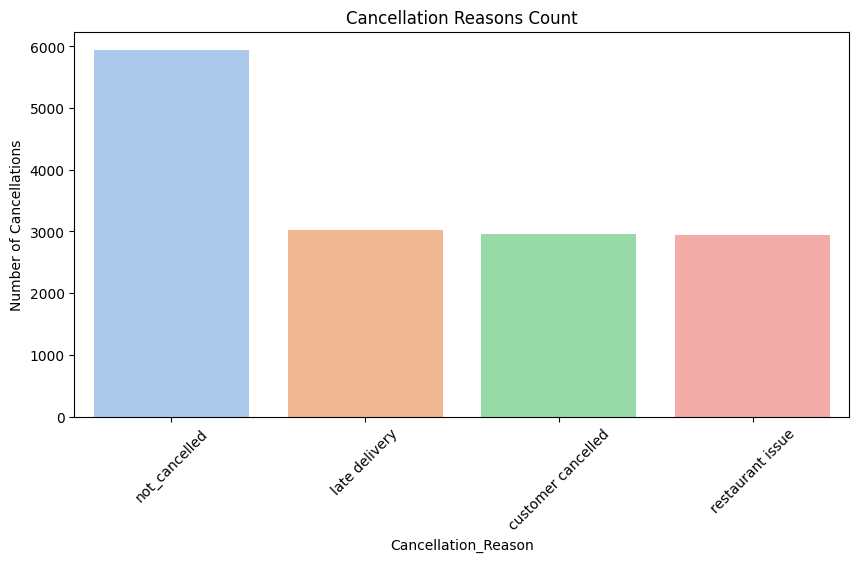

In [ ]:
cancel_counts = cancelled_df['Cancellation_Reason'].value_counts()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(x=cancel_counts.index, y=cancel_counts.values, palette='pastel')
plt.xticks(rotation=45)
plt.ylabel("Number of Cancellations")
plt.title("Cancellation Reasons Count")
plt.show()


/tmp/ipython-input-1718367508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancel_percentage.index, y=cancel_percentage.values, palette='muted')


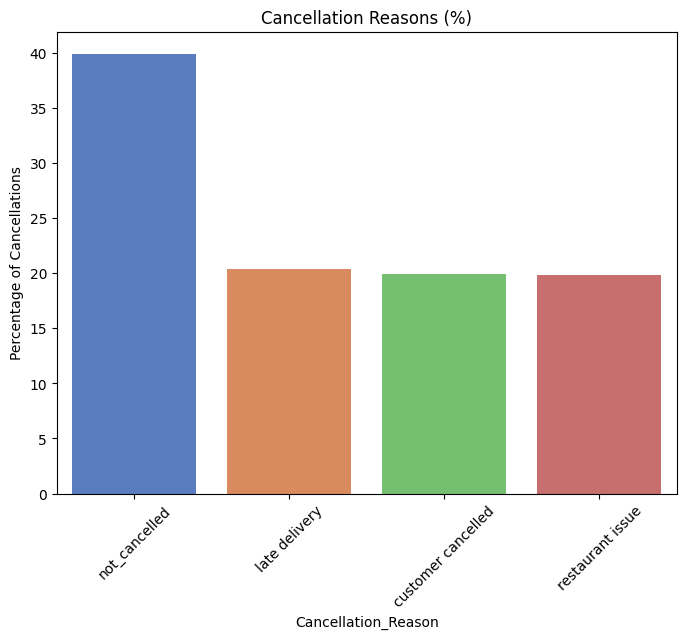

In [ ]:
cancel_percentage = cancelled_df['Cancellation_Reason'].value_counts(normalize=True) * 100

plt.figure(figsize=(8,6))
sns.barplot(x=cancel_percentage.index, y=cancel_percentage.values, palette='muted')
plt.xticks(rotation=45)
plt.ylabel("Percentage of Cancellations")
plt.title("Cancellation Reasons (%)")
plt.show()


/tmp/ipython-input-1268298217.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_cancel_rate.index, y=city_cancel_rate.values, palette='cool')


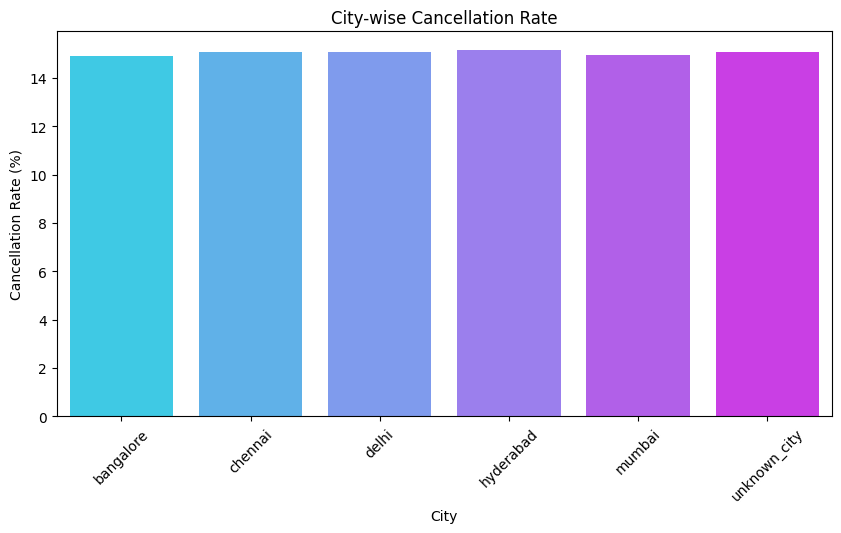

In [ ]:
city_cancel_rate = df.groupby('City')['Order_Status'].apply(
    lambda x: (x=='cancelled').sum() / len(x) * 100
)

plt.figure(figsize=(10,5))
sns.barplot(x=city_cancel_rate.index, y=city_cancel_rate.values, palette='cool')
plt.xticks(rotation=45)
plt.ylabel("Cancellation Rate (%)")
plt.title("City-wise Cancellation Rate")
plt.show()


/tmp/ipython-input-3069492764.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_cancel_rate.index, y=cuisine_cancel_rate.values, palette='Set2')


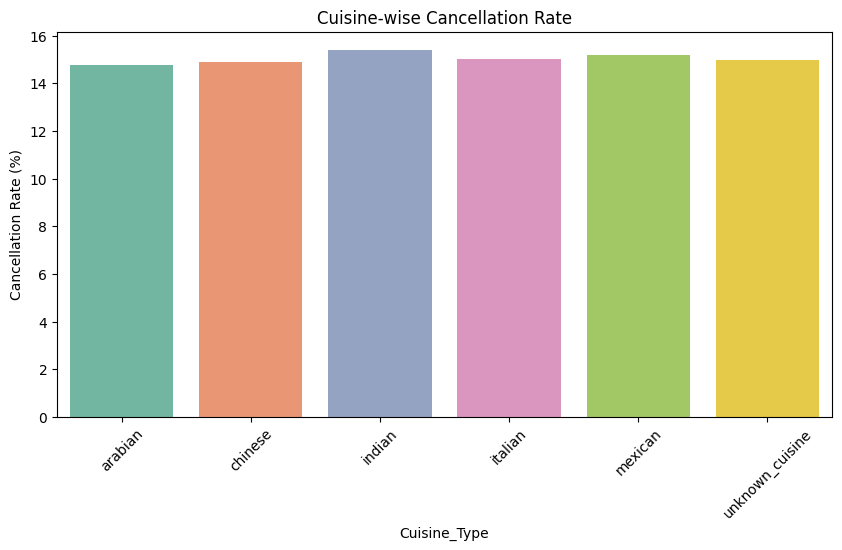

In [ ]:
cuisine_cancel_rate = df.groupby('Cuisine_Type')['Order_Status'].apply(
    lambda x: (x=='cancelled').sum() / len(x) * 100
)

plt.figure(figsize=(10,5))
sns.barplot(x=cuisine_cancel_rate.index, y=cuisine_cancel_rate.values, palette='Set2')
plt.xticks(rotation=45)
plt.ylabel("Cancellation Rate (%)")
plt.title("Cuisine-wise Cancellation Rate")
plt.show()


In [ ]:
numeric_cols = [
    'Customer_Age', 'Delivery_Time_Min', 'Distance_km', 'Order_Value',
    'Discount_Applied', 'Final_Amount', 'Delivery_Rating',
    'Restaurant_Rating', 'Profit_Margin'
]

numeric_df = df[numeric_cols]


In [ ]:
corr_matrix = numeric_df.corr()
corr_matrix


,Customer_Age,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Delivery_Rating,Restaurant_Rating,Profit_Margin
Customer_Age,1.000000,-0.011180,-0.001595,-0.002048,0.001976,-0.002196,0.000080,0.001366,0.001296
Delivery_Time_Min,-0.011180,1.000000,0.004560,0.001592,-0.001748,0.001725,0.002811,0.002951,-0.002912
Distance_km,-0.001595,0.004560,1.000000,0.000990,0.003360,0.000724,-0.000462,0.002885,0.003064
Order_Value,-0.002048,0.001592,0.000990,1.000000,0.000178,0.996934,0.001276,-0.003914,-0.002724
Discount_Applied,0.001976,-0.001748,0.003360,0.000178,1.000000,-0.078063,0.000840,0.004322,0.004712
Final_Amount,-0.002196,0.001725,0.000724,0.996934,-0.078063,1.000000,0.001207,-0.004240,-0.003085
Delivery_Rating,0.000080,0.002811,-0.000462,0.001276,0.000840,0.001207,1.000000,0.001440,0.000189
Restaurant_Rating,0.001366,0.002951,0.002885,-0.003914,0.004322,-0.004240,0.001440,1.000000,-0.000905
Profit_Margin,0.001296,-0.002912,0.003064,-0.002724,0.004712,-0.003085,0.000189,-0.000905,1.000000


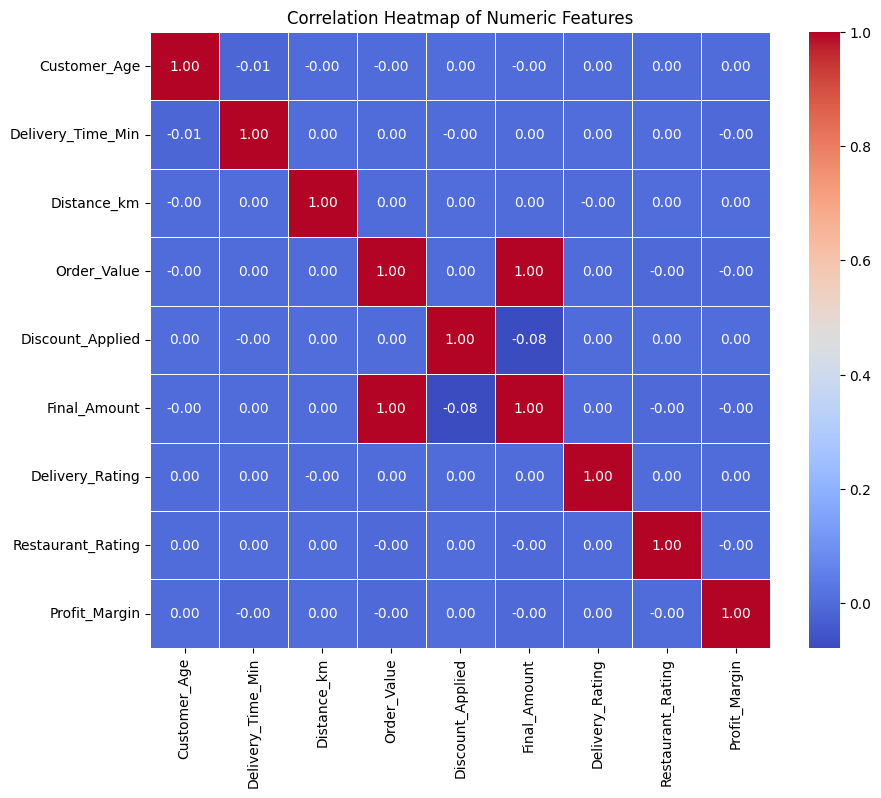

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


Feature Engineering

In [ ]:
# Ensure Order_Date is datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Extract day of week (Monday=0, Sunday=6)
df['Day_of_Week'] = df['Order_Date'].dt.dayofweek

# Define Weekend / Weekday
df['Order_Day_Type'] = df['Day_of_Week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')


In [ ]:
# Convert Order_Time to datetime, infer format
df['Order_Time'] = pd.to_datetime(df['Order_Time'], errors='coerce').dt.hour


In [ ]:
def peak_hour(hour):
    if 11 <= hour <= 14:
        return 'Lunch Peak'
    elif 19 <= hour <= 22:
        return 'Dinner Peak'
    else:
        return 'Off-Peak'

df['Peak_Hour_Indicator'] = df['Order_Time'].apply(peak_hour)


In [ ]:
df['Profit_Margin_Percent'] = df['Profit_Margin'] * 100


In [ ]:
def delivery_performance(time):
    if time < 30:
        return 'Fast'
    elif 30 <= time <= 60:
        return 'On-Time'
    elif 61 <= time <= 90:
        return 'Slightly Late'
    else:
        return 'Delayed'

# Only apply to delivered orders
df.loc[df['Order_Status']=='delivered', 'Delivery_Performance'] = df.loc[df['Order_Status']=='delivered', 'Delivery_Time_Min'].apply(delivery_performance)


In [ ]:
def age_group(age):
    if 13 <= age <= 19:
        return 'Teenager'
    elif 20 <= age <= 29:
        return 'Young Adult'
    elif 30 <= age <= 44:
        return 'Adult'
    elif 45 <= age <= 59:
        return 'Middle Age'
    elif age >= 60:
        return 'Senior'
    else:
        return 'Unknown'  # for missing or invalid ages

df['Customer_Age_Group'] = df['Customer_Age'].apply(age_group)


In [ ]:
csv=df.to_csv('cleaned_data.csv', index=False)

In [ ]:
# import pandas as pd

# # Load CSV
# df = pd.read_csv("../data/cleaned_data.csv")

# # Convert DD-MM-YYYY → YYYY-MM-DD
# df["Order_Date"] = pd.to_datetime(
#     df["Order_Date"],
#     format="%d-%m-%Y",
#     errors="coerce"
# )

# # Drop invalid dates (optional but safe)
# df = df.dropna(subset=["Order_Date"])

# # Save back to SAME CSV (overwrite)
# df.to_csv("../data/cleaned_data1.csv", index=False)

# print("✅ CSV file updated with correct date format")

Index(['Order_ID', 'Customer_ID', 'Customer_Age', 'Customer_Gender', 'City',
       'Area', 'Restaurant_ID', 'Restaurant_Name', 'Cuisine_Type',
       'Order_Date', 'Order_Time', 'Delivery_Time_Min', 'Distance_km',
       'Order_Value', 'Discount_Applied', 'Final_Amount', 'Payment_Mode',
       'Order_Status', 'Cancellation_Reason', 'Delivery_Partner_ID',
       'Delivery_Rating', 'Restaurant_Rating', 'Order_Day', 'Peak_Hour',
       'Profit_Margin', 'Day_of_Week', 'Day_Type', 'Order_Day_Type',
       'Peak_Hour_Indicator', 'Profit_Margin_Percent', 'Delivery_Performance',
       'Customer_Age_Group'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98986 entries, 0 to 99998
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Order_ID               98986 non-null  object        
 1   Customer_ID            98986 non-null  object        
 2   Customer_Age           98986 non-null  float64       
 3   Customer_Gender        98986 non-null  object        
 4   City                   98986 non-null  object        
 5   Area                   98986 non-null  object        
 6   Restaurant_ID          98986 non-null  object        
 7   Restaurant_Name        98986 non-null  object        
 8   Cuisine_Type           98986 non-null  object        
 9   Order_Date             98986 non-null  datetime64[ns]
 10  Order_Time             98986 non-null  int32         
 11  Delivery_Time_Min      84100 non-null  float64       
 12  Distance_km            98986 non-null  float64       
 13  Order_